In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [2]:
water_quality_dataset = pd.read_csv(r"C:\Users\CJ\Downloads\waterQuality1.csv")

In [3]:
water_quality_dataset.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
water_quality_dataset.isnull().sum()

aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64

In [5]:
water_quality_dataset.describe()

,aluminium,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
count,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000,7999.000000
mean,0.666158,0.161445,1.567715,0.042806,2.176831,0.247226,0.805857,0.771565,0.319665,0.328583,0.099450,9.818822,1.329961,0.005194,16.460299,2.920548,0.049685,0.147781,0.044673
std,1.265145,0.252590,1.216091,0.036049,2.567027,0.270640,0.653539,0.435373,0.329485,0.378096,0.058172,5.541331,0.573219,0.002967,17.687474,2.323009,0.028770,0.143551,0.026904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.405000,0.000000,0.002000,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000
50%,0.070000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,0.008000,0.102000,9.930000,1.420000,0.005000,7.740000,2.410000,0.050000,0.080000,0.050000
75%,0.280000,0.100000,2.480000,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,0.700000,0.151000,14.610000,1.760000,0.008000,29.480000,4.670000,0.070000,0.240000,0.070000
max,5.050000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,1.000000,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000


## value_counts are used when we r doing classification model 
* if classification value are balanced means ok are the model gives error

In [6]:
water_quality_dataset["is_safe"].value_counts()
# NUM NON num value

is_safe
0        7084
1         912
#NUM!       3
Name: count, dtype: int64

In [7]:
# Step 1: Replace '#NUM!' with NaN
import numpy as np

water_quality_dataset['is_safe'] = water_quality_dataset['is_safe'].replace('#NUM!', np.nan)

# Step 2: Drop those rows
water_quality_dataset = water_quality_dataset.dropna(subset=['is_safe'])

# Step 3: Convert to integer
water_quality_dataset['is_safe'] = water_quality_dataset['is_safe'].astype(int)

In [8]:
water_quality_dataset["is_safe"].value_counts()

is_safe
0    7084
1     912
Name: count, dtype: int64

<Axes: >

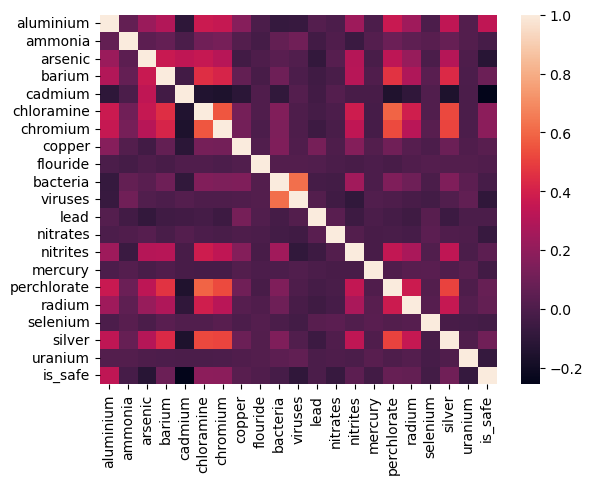

In [9]:
sns.heatmap(data = water_quality_dataset.corr())

In [10]:
water_quality_dataset.corr()['is_safe'].sort_values(ascending = False)

is_safe        1.000000
aluminium      0.333974
chloramine     0.186704
chromium       0.182306
silver         0.102813
barium         0.090858
perchlorate    0.075735
radium         0.064743
nitrites       0.046986
copper         0.029498
flouride       0.006550
lead          -0.009970
bacteria      -0.022077
ammonia       -0.022919
selenium      -0.030923
mercury       -0.036817
nitrates      -0.072100
uranium       -0.075619
viruses       -0.097040
arsenic       -0.123362
cadmium       -0.256034
Name: is_safe, dtype: float64

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scalar = StandardScaler()
X= water_quality_dataset.drop('is_safe',axis =1)
Y = water_quality_dataset['is_safe']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, stratify = Y)
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000 , class_weight = 'balanced')
model.fit(X_train , Y_train)
y_pred = model.predict(X_test)
print(classification_report(Y_test , y_pred))

              precision    recall  f1-score   support

           0       0.98      0.79      0.87      1418
           1       0.34      0.85      0.48       182

    accuracy                           0.79      1600
   macro avg       0.66      0.82      0.68      1600
weighted avg       0.90      0.79      0.83      1600



In [13]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scalar = StandardScaler()
X= water_quality_dataset.drop('is_safe',axis =1)
Y = water_quality_dataset['is_safe']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, stratify = Y)

X_train,Y_train = smote.fit_resample(X_train,Y_train) 
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

model = LogisticRegression(max_iter=1000 )
model.fit(X_train , Y_train)
y_pred = model.predict(X_test)
print(classification_report(Y_test , y_pred))


              precision    recall  f1-score   support

           0       0.97      0.81      0.88      1418
           1       0.35      0.78      0.48       182

    accuracy                           0.81      1600
   macro avg       0.66      0.80      0.68      1600
weighted avg       0.90      0.81      0.84      1600



In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    min_samples_split = 5,
    class_weight = 'balanced',
    random_state = 42)
model.fit(X_train , Y_train)
y_pred = model.predict(X_test)
print(classification_report(Y_test , y_pred))


              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1418
           1       0.71      0.92      0.80       182

    accuracy                           0.95      1600
   macro avg       0.85      0.93      0.89      1600
weighted avg       0.96      0.95      0.95      1600



In [15]:
importance = model.feature_importances_
feature_name = X.columns
pd.DataFrame ({
    'feature' : feature_name,
     'importance' : importance
        }).sort_values(by = 'importance',ascending = False)

,feature,importance
0,aluminium,0.242866
4,cadmium,0.096036
5,chloramine,0.071546
2,arsenic,0.069164
15,perchlorate,0.062551
10,viruses,0.060302
18,silver,0.057830
6,chromium,0.045690
19,uranium,0.044637
13,nitrites,0.040131


<function matplotlib.pyplot.show(close=None, block=None)>

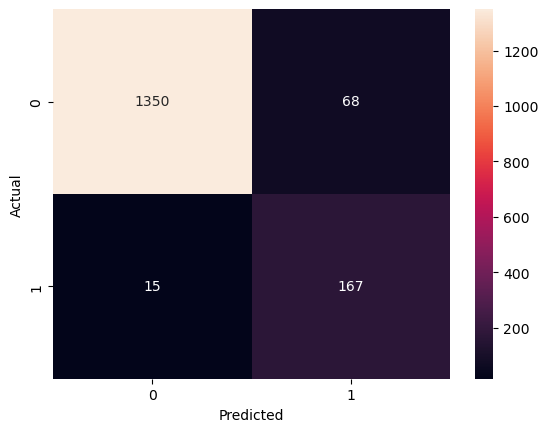

In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test , y_pred)
sns.heatmap(cm,annot = True,fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

In [ ]:
pip install --upgrade scikit-learn 

In [ ]:
print(X.dtypes)
print(Y.unique())

In [ ]:
X = X.apply(pd.to_numeric,errors = 'coerce')
X = X.dropna()
Y = Y[X.index]

In [ ]:
print(X.dtypes)